# Image to Images

In [1]:
from PIL import Image

img = Image.open("cat01.jpg")
img.show()

In [3]:
image_files = ["cat01.jpg", "cat02.jpg", "dog01.jpg", "dog02.jpg"]

for file in image_files:
    img = Image.open(file)
    print(file, img.size)
    img.show()

cat01.jpg (612, 503)
cat02.jpg (750, 459)
dog01.jpg (540, 360)
dog02.jpg (1480, 708)


# Imagelarni tartiblash

In [8]:
import os

folders = [
    "dataset/train/books",
    "dataset/train/pens",
    "dataset/train/pencils",
    "dataset/train/notebooks"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [9]:
import os
import shutil

files_to_copy = {
    "book.jpeg": "dataset/train/books/book.jpeg",
    "pen.jpeg": "dataset/train/pens/pen.jpeg",
    "pencil.jpeg": "dataset/train/pencils/pencil.jpeg",
    "notebook.jpeg": "dataset/train/notebooks/notebook.jpeg"
}

for src, dst in files_to_copy.items():
    shutil.copy(src, dst)

print("Images copied successfully.")

Images copied successfully.


In [10]:
import os

train_path = "dataset/train"

classes = os.listdir(train_path)

print("Classes found:", classes)

Classes found: ['books', 'notebooks', 'pencils', 'pens']


# Image -> Label

In [16]:
samples = [
    ("book.jpeg", 0),
    ("notebook.jpeg", 1),
    ("pen.jpeg", 2),
    ("pencil.jpeg", 3)
]

print("First sample:", samples[0])

First sample: ('book.jpeg', 0)


In [14]:
samples = [
    {"image": "book.jpeg", "label": 0},
    {"image": "notebook.jpeg", "label": 1},
    {"image": "pen.jpeg", "label": 2},
    {"image": "pencil.jpeg", "label": 3}
]

print("First sample:", samples[0])

First sample: {'image': 'book.jpeg', 'label': 0}


# Preprocessing= Transforms

In [17]:
from PIL import Image

samples = [
    ("book.jpeg", 0),
    ("notebook.jpeg", 1),
    ("pen.jpeg", 2),
    ("pencil.jpeg", 3)
]

image_file, label = samples[0]

img = Image.open(image_file)
print("Original image:", image_file)
print("Original size:", img.size)
print("Label:", label)

resized_img = img.resize((128, 128))
print("Resized size:", resized_img.size)

resized_img.show()

Original image: book.jpeg
Original size: (300, 168)
Label: 0
Resized size: (128, 128)


Image file: book.jpeg
Label: 0
Original size: (300, 168)
Resized size: (128, 128)


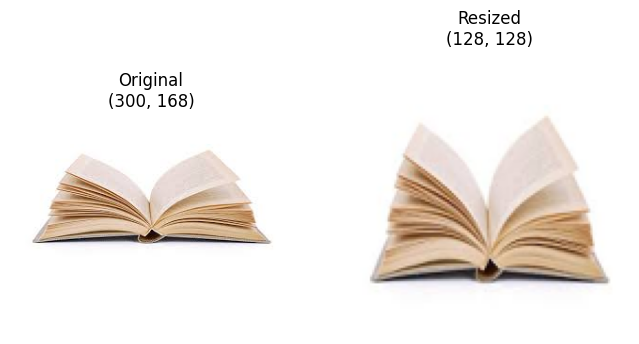

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

samples = [
    ("book.jpeg", 0),
    ("notebook.jpeg", 1),
    ("pen.jpeg", 2),
    ("pencil.jpeg", 3)
]

image_file, label = samples[0]

img = Image.open(image_file)
resized_img = img.resize((128, 128))

print("Image file:", image_file)
print("Label:", label)
print("Original size:", img.size)
print("Resized size:", resized_img.size)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f"Original\n{img.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_img)
plt.title(f"Resized\n{resized_img.size}")
plt.axis("off")

plt.show()

Original size: (300, 168)
Cropped size: (150, 120)


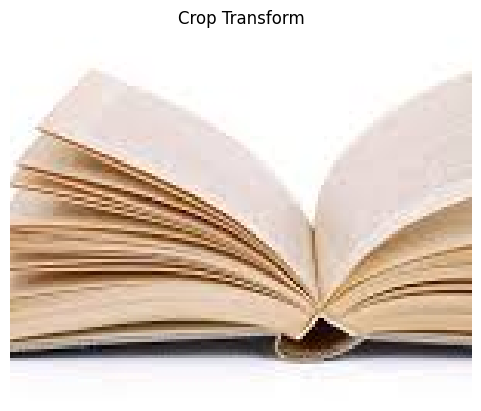

In [19]:
# Crop
cropped_img = img.crop((50, 30, 200, 150))
# (left, top, right, bottom)

print("Original size:", img.size)
print("Cropped size:", cropped_img.size)

plt.imshow(cropped_img)
plt.title("Crop Transform")
plt.axis("off")
plt.show()

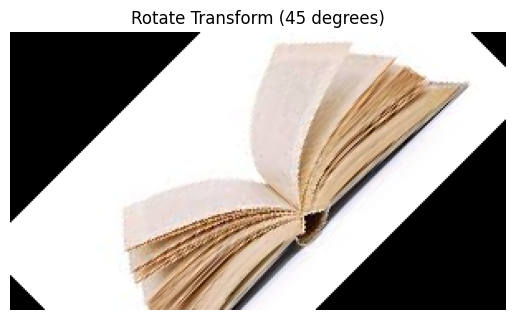

In [20]:
# rotate
rotated_img = img.rotate(45)

plt.imshow(rotated_img)
plt.title("Rotate Transform (45 degrees)")
plt.axis("off")
plt.show()

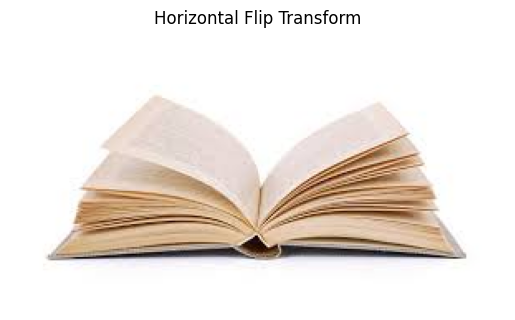

In [24]:
# Gorizantal flip
flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)

plt.imshow(flipped_img)
plt.title("Horizontal Flip Transform")
plt.axis("off")
plt.show()

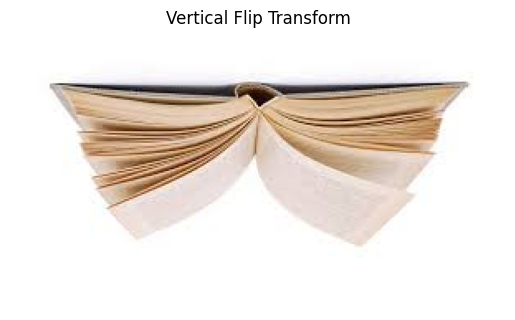

In [25]:
#Vertical
vertical_flip_img = img.transpose(Image.FLIP_TOP_BOTTOM)

plt.imshow(vertical_flip_img)
plt.title("Vertical Flip Transform")
plt.axis("off")
plt.show()

Grayscale size: (300, 168)


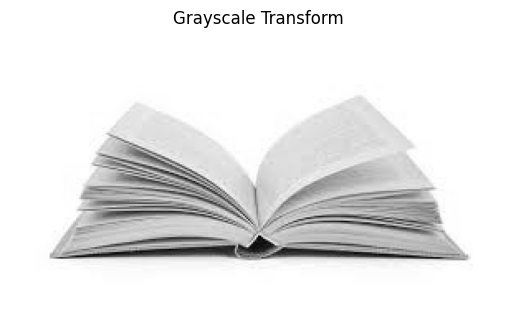

In [27]:
# Grayscale transform
gray_img = img.convert("L")

print("Grayscale size:", gray_img.size)

plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Transform")
plt.axis("off")
plt.show()

Array shape: (168, 300, 3)
Array type: <class 'numpy.ndarray'>


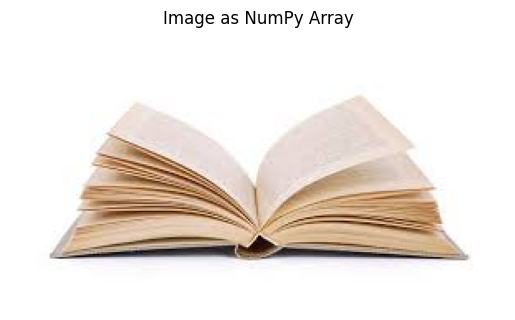

In [29]:
# RGB to numpy
import numpy as np
img_array = np.array(img)

print("Array shape:", img_array.shape)
print("Array type:", type(img_array))

plt.imshow(img_array)
plt.title("Image as NumPy Array")
plt.axis("off")
plt.show()

Min value: 0.0
Max value: 1.0
Shape: (168, 300, 3)


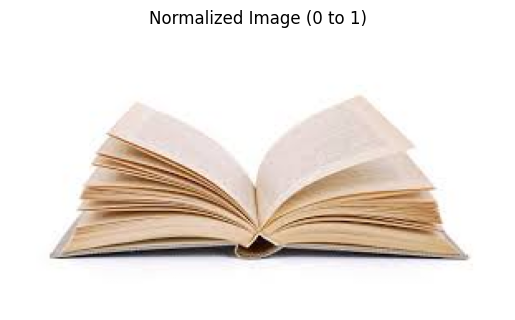

In [30]:
#Normalization
img_array = np.array(img).astype(np.float32) / 255.0

print("Min value:", img_array.min())
print("Max value:", img_array.max())
print("Shape:", img_array.shape)

plt.imshow(img_array)
plt.title("Normalized Image (0 to 1)")
plt.axis("off")
plt.show()

Final shape: (128, 128)
Min: 0.019607844
Max: 1.0


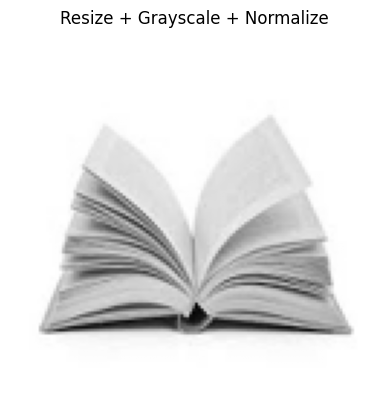

In [32]:
#Resize + Grayscale + Normalize Together
img = Image.open(image_file)

img = img.resize((128, 128))


img = img.convert("L")

img_array = np.array(img).astype(np.float32)

img_array = img_array / 255.0

print("Final shape:", img_array.shape)
print("Min:", img_array.min())
print("Max:", img_array.max())

plt.imshow(img_array, cmap="gray")
plt.title("Resize + Grayscale + Normalize")
plt.axis("off")
plt.show()

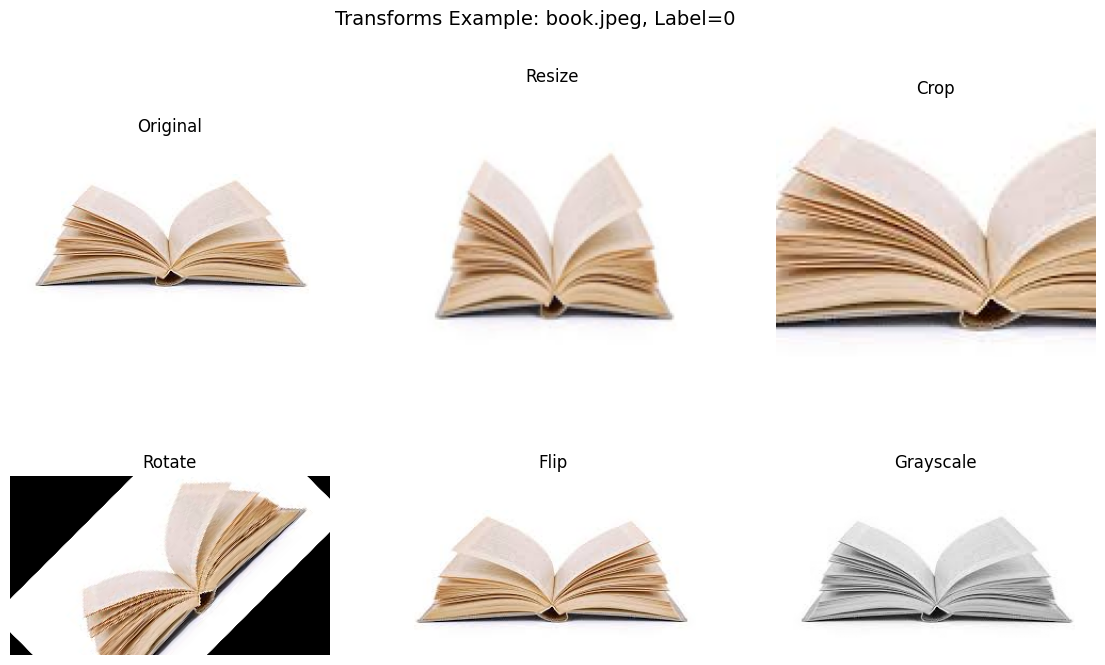

In [33]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

samples = [
    ("book.jpeg", 0),
    ("notebook.jpeg", 1),
    ("pen.jpeg", 2),
    ("pencil.jpeg", 3)
]

image_file, label = samples[0]
img = Image.open(image_file)

resized_img = img.resize((128, 128))
cropped_img = img.crop((50, 30, 200, 150))
rotated_img = img.rotate(45)
flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)
gray_img = img.convert("L")

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(resized_img)
plt.title("Resize")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(cropped_img)
plt.title("Crop")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(rotated_img)
plt.title("Rotate")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(flipped_img)
plt.title("Flip")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.suptitle(f"Transforms Example: {image_file}, Label={label}", fontsize=14)
plt.show()